# BarkWatch — Project Presentation

**Arnes Hackathon 2026**

Forecasting bark beetle harvest activity across Slovenian forest parcels (odseki) for up to 12 months ahead, using LightGBM two-stage horizon models trained on ZGS harvest records and ARSO weather data.  
A parallel track trains on *synthetic* bark beetle population data generated by a temperature-driven logistic-growth simulation.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib

ROOT = Path('.')
sys.path.insert(0, str(ROOT))

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Ready.')

Ready.


---
## 1. Raw & Processed Data

### 1.1 Target — bark beetle harvest per odsek per month (`target.csv`)

The target contains 12 forward horizons (`h1`–`h12`) per `(odsek, leto_mesec)` row, stored in **log1p space** (natural log of 1 + m³ harvested) to compress the heavy right tail of harvest volumes.

Shape: (3131352, 15)


,ggo,odsek,leto_mesec,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12
0,1,01004A,2007-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,01004A,2007-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,01004A,2007-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,01004A,2007-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,01004A,2007-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


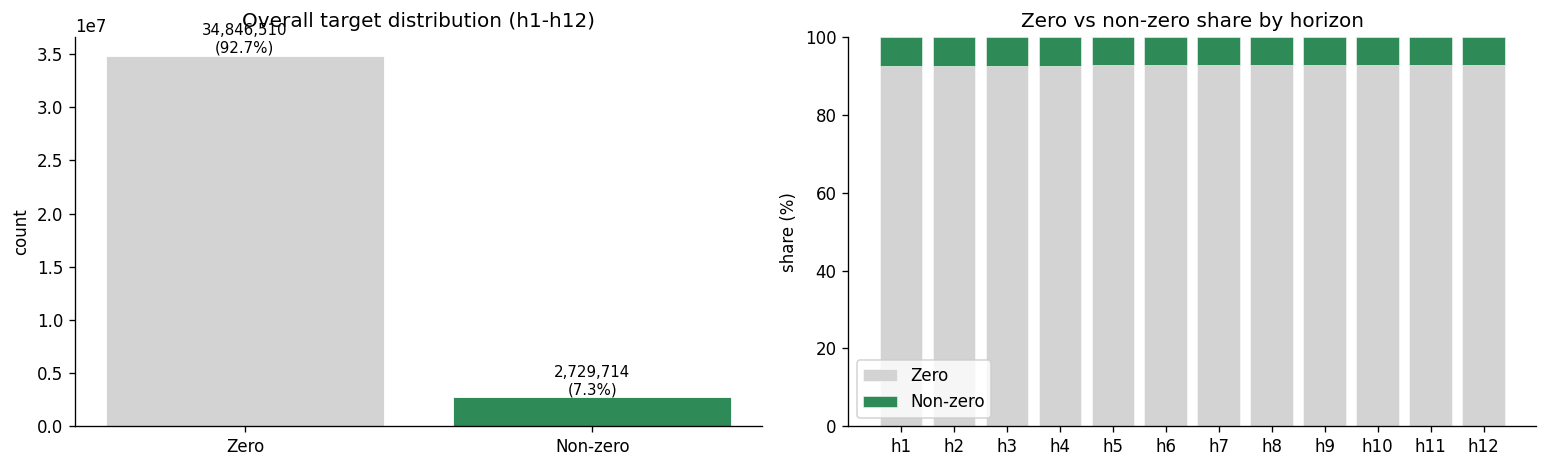


% non-zero rows per horizon:
h1     7.42
h2     7.40
h3     7.37
h4     7.35
h5     7.31
h6     7.28
h7     7.26
h8     7.22
h9     7.18
h10    7.15
h11    7.13
h12    7.08


In [2]:
target = pd.read_csv('data/processed/target.csv', low_memory=False)
print(f'Shape: {target.shape}')
display(target.head(5))

h_cols = [f'h{i}' for i in range(1, 13)]
is_nonzero = target[h_cols] > 0

overall_counts = pd.Series({
    'Zero': int((~is_nonzero).sum().sum()),
    'Non-zero': int(is_nonzero.sum().sum()),
})
overall_pct = (overall_counts / overall_counts.sum() * 100).round(2)

nonzero_pct = (is_nonzero.mean() * 100).round(2)
zero_pct = 100 - nonzero_pct

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar(
    overall_counts.index,
    overall_counts.values,
    color=['lightgray', 'seagreen'],
    edgecolor='white',
    linewidth=0.5,
)
axes[0].set_title('Overall target distribution (h1-h12)')
axes[0].set_ylabel('count')
for bar, count, pct in zip(bars, overall_counts.values, overall_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9,
    )

axes[1].bar(
    h_cols,
    zero_pct.values,
    color='lightgray',
    label='Zero',
    edgecolor='white',
    linewidth=0.3,
)
axes[1].bar(
    h_cols,
    nonzero_pct.values,
    bottom=zero_pct.values,
    color='seagreen',
    label='Non-zero',
    edgecolor='white',
    linewidth=0.3,
)
axes[1].set_ylim(0, 100)
axes[1].set_title('Zero vs non-zero share by horizon')
axes[1].set_ylabel('share (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n% non-zero rows per horizon:')
print(nonzero_pct.to_string())

### 1.2 ZGS Harvest Records — raw posek (`posek.csv`) → processed (`posek_processed.csv`)

The raw ZGS harvest table records individual cutting events per forest parcel (`odsek`) and month.  
Processing aggregates these into monthly totals per `(ggo, odsek, leto_mesec)` and computes lag/rolling features.

In [3]:
posek_raw = pd.read_csv('data/raw/ZGS/posek.csv', low_memory=False)
print(f'Raw posek — shape: {posek_raw.shape}')
display(posek_raw.head(4))
print(f'\nDate range: {posek_raw["posekano"].min()} — {posek_raw["posekano"].max()}')
print(f'Unique odsek: {posek_raw["odsek"].nunique():,}')

Raw posek — shape: (450064, 8)


,ggo,odsek,manual,kubikov,vrsec,posekano,ko,parcela
0,1,01026A,07001,22.73,301,2007-01-01,2204,1
1,1,01064B,07001,20.18,301,2007-02-01,2210,1
2,1,01064B,07002,7.56,301,2007-03-01,2210,1
3,1,01076A,07001,8.61,301,2007-01-01,2210,1



Date range: 2007-01-01 — 2025-12-31
Unique odsek: 25,691


Processed posek — shape: (450061, 11)


,ggo,odsek,manual,kubikov,vrsec,posekano,ko,parcela,leto,mesec,leto_mesec
0,1,01026A,NaN,22.73,301,2007-01-01,2204,1,2007,1,2007-01
1,1,01076A,NaN,8.61,301,2007-01-01,2210,1,2007,1,2007-01
2,1,01076A,NaN,13.62,301,2007-01-01,2210,1,2007,1,2007-01
3,1,01086A,NaN,2.88,301,2007-01-01,2209,1,2007,1,2007-01


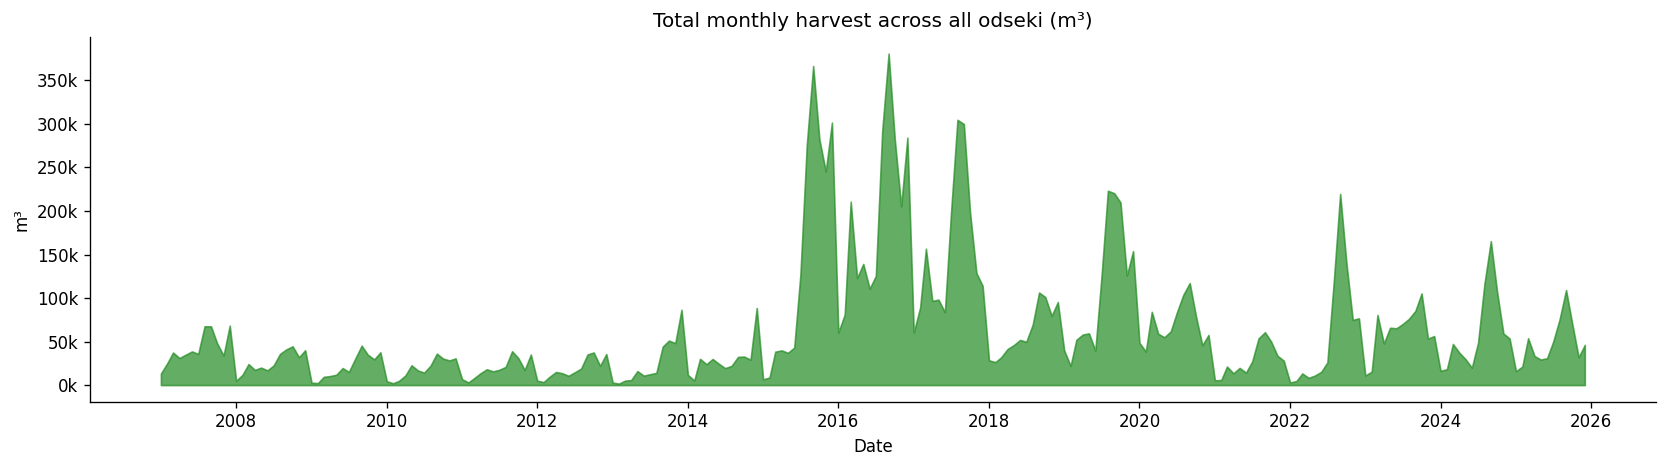

In [4]:
posek_proc = pd.read_csv('data/processed/posek_processed.csv', low_memory=False)
posek_proc['leto_mesec'] = posek_proc['leto'].astype(str) + '-' + posek_proc['mesec'].astype(str).str.zfill(2)
print(f'Processed posek — shape: {posek_proc.shape}')
display(posek_proc.head(4))

monthly = posek_proc.groupby('leto_mesec')['kubikov'].sum().reset_index()
monthly['date'] = pd.to_datetime(monthly['leto_mesec'])
monthly = monthly.sort_values('date')

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly['date'], monthly['kubikov'], alpha=0.7, color='forestgreen')
ax.set_title('Total monthly harvest across all odseki (m³)')
ax.set_xlabel('Date')
ax.set_ylabel('m³')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}k"))
plt.tight_layout()
plt.show()

### 1.3 ZGS Forest Parcels — `odseki_gozdno.gpkg` + `sestoji.gpkg` → `odseki_processed.csv` + `sestoji_processed.csv`

Forest parcel geometry (GeoPackage) is processed into tabular form.  
`odseki_processed.csv` contains structural attributes (area, slope, altitude, tariff groups, forest type flags) for each `(ggo, odsek)`.  
`sestoji_processed.csv` adds stand-level attributes (species composition, stand phase, canopy closure).

In [5]:
odseki = pd.read_csv('data/processed/odseki_processed.csv', low_memory=False)
print(f'odseki_processed — shape: {odseki.shape}')
display(odseki[['ggo','odsek','povrsina','nagib','nvod','nvdo','tarifa_sm','tarifa_je']].head(5))

sestoji = pd.read_csv('data/processed/sestoji_processed.csv', low_memory=False)
print(f'\nsestoji_processed — shape: {sestoji.shape}')
display(sestoji[['ggo','odsek','sestoj','povrsina','lzskdv11','lzskdv21','lzigl','lzlst','lzsku']].head(5))

odseki_processed — shape: (53254, 63)


,ggo,odsek,povrsina,nagib,nvod,nvdo,tarifa_sm,tarifa_je
0,9,31001,16.57,20,820,910,52,52
1,9,31002,31.37,20,675,825,34,33
2,9,31003,20.00,25,850,1040,52,52
3,9,31004,23.42,25,830,960,52,52
4,9,31005,18.53,30,920,1150,52,52



sestoji_processed — shape: (350593, 56)


,ggo,odsek,sestoj,povrsina,lzskdv11,lzskdv21,lzigl,lzlst,lzsku
0,1,01001A,A212,5.90,43.23,1.16,796.0,150.0,946.0
1,1,01001A,A213,16.92,32.32,1.91,4561.0,996.0,5557.0
2,1,01001A,A214,4.19,18.98,4.49,625.0,1066.0,1691.0
3,1,01001B,A212,47.09,43.17,1.14,6039.0,1145.0,7184.0
4,1,01001B,A213,0.62,32.14,2.04,161.0,35.0,196.0


### 1.4 ARSO Weather Data — `data/raw/ARSO/*` → `vreme_mesecno.csv`

Monthly climate summaries from ARSO weather stations (2007–2025).  
Processing computes year-over-year deltas, rolling averages, and drought stress proxies.  
Each forest parcel is assigned its nearest weather station.

vreme_mesecno — shape: (51167, 26)


,station_id,leto_mesec,povp_T_avg,max_T_mesec,min_T_mesec,padavine_skupaj_mm,dni_s_padavinami,snezna_odeja_max_cm
0,43,2008-01,NaN,NaN,NaN,138.2,17,3.0
1,43,2008-02,NaN,NaN,NaN,60.5,6,10.0
2,43,2008-03,NaN,NaN,NaN,215.0,23,45.0
3,43,2008-04,NaN,NaN,NaN,253.6,19,0.0
4,43,2008-05,NaN,NaN,NaN,119.3,17,0.0


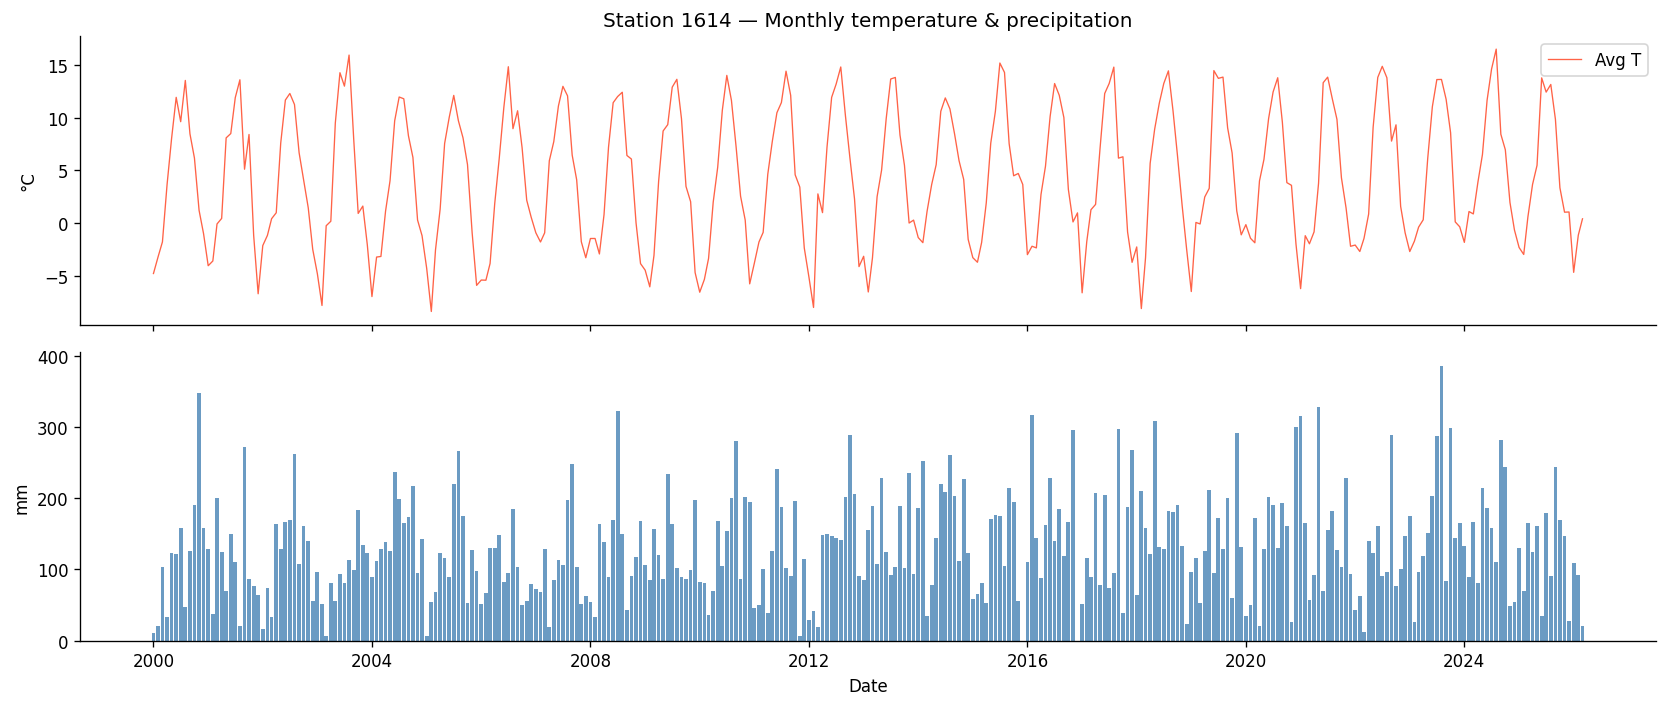


Unique stations: 217
Date range: 2000-01 — 2026-03


In [6]:
vreme = pd.read_csv('data/processed/vreme_mesecno.csv', low_memory=False)
print(f'vreme_mesecno — shape: {vreme.shape}')
display(vreme[['station_id','leto_mesec','povp_T_avg','max_T_mesec','min_T_mesec',
               'padavine_skupaj_mm','dni_s_padavinami','snezna_odeja_max_cm']].head(5))

station_sample = vreme[vreme['station_id'] == vreme['station_id'].value_counts().idxmax()].copy()
station_sample['date'] = pd.to_datetime(station_sample['leto_mesec'])
station_sample = station_sample.sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(station_sample['date'], station_sample['povp_T_avg'], color='tomato', linewidth=0.8, label='Avg T')
axes[0].set_title(f'Station {station_sample["station_id"].iloc[0]} — Monthly temperature & precipitation')
axes[0].set_ylabel('°C')
axes[0].legend()

axes[1].bar(station_sample['date'], station_sample['padavine_skupaj_mm'], width=25, color='steelblue', alpha=0.8)
axes[1].set_ylabel('mm')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

print(f'\nUnique stations: {vreme["station_id"].nunique()}')
print(f'Date range: {vreme["leto_mesec"].min()} — {vreme["leto_mesec"].max()}')

---
## 2. Aggregated & Train/Val/Test Data

### 2.1 Aggregated Features

Two aggregate tables extend the base features:

| File | Description |
|------|-------------|
| `agg_posek_meritve.csv` | Weather station features joined to each parcel per month (annual rolling temperature, precipitation, drought stress) |
| `agg_posek_sosedi.csv` | Spatial neighbour features — sum/mean of lagged harvest and rolling stats across the nearest neighbouring parcels |

In [7]:
agg_meritve = pd.read_csv('data/processed/agg_posek_meritve.csv', nrows=50000, low_memory=False)
print(f'agg_posek_meritve — {len(agg_meritve):,} rows (sample), {agg_meritve.shape[1]} columns')
display(agg_meritve[['ggo','odsek_id','leto_mesec','leto_povp_T_avg','leto_max_T_mesec',
                      'leto_min_T_mesec','leto_padavine_skupaj_mm','leto_dni_s_padavinami']].head(4))

agg_posek_meritve — 50,000 rows (sample), 17 columns


,ggo,odsek_id,leto_mesec,leto_povp_T_avg,leto_max_T_mesec,leto_min_T_mesec,leto_padavine_skupaj_mm,leto_dni_s_padavinami
0,1,01003A,2010-09,6.832,31.8,-21.2,1555.1,152.0
1,1,01003A,2010-10,6.729,31.8,-21.2,1582.0,155.0
2,1,01003A,2010-11,6.687,31.8,-21.2,1814.9,164.0
3,1,01003A,2010-12,6.538,31.8,-19.0,1703.4,168.0


In [8]:
agg_sosedi = pd.read_csv('data/processed/agg_posek_sosedi.csv', nrows=50000, low_memory=False)
print(f'agg_posek_sosedi — {len(agg_sosedi):,} rows (sample), {agg_sosedi.shape[1]} columns')
display(agg_sosedi[['ggo','odsek_id','leto_mesec','sosedi_lag_1_sum','sosedi_lag_1_mean',
                     'sosedi_rolling_mean_12_mean','sosedi_st_sosedov']].head(4))

agg_posek_sosedi — 50,000 rows (sample), 16 columns


,ggo,odsek_id,leto_mesec,sosedi_lag_1_sum,sosedi_lag_1_mean,sosedi_rolling_mean_12_mean,sosedi_st_sosedov
0,1,01001A,2007-01,NaN,NaN,0.0965,4
1,1,01001A,2007-02,3.1667,0.7917,0.1443,4
2,1,01001A,2007-03,0.0000,0.0000,0.1443,4
3,1,01001A,2007-04,0.0000,0.0000,0.1443,4


### 2.2 Train / Val / Test Split

The data is split **temporally** (no odsek overlap between splits) to prevent leakage:

| Split | Date range | Purpose |
|-------|------------|---------|
| **Train** | `2010-09` – `2021-12` | Model fitting |
| **Val** | `2022-01` – `2023-06` | Early stopping & threshold tuning |
| **Test** | `2023-07` – `2024-12` | Final held-out evaluation |

Each row represents one `(odsek, leto_mesec)` context window with time-series lag/rolling features as input and 12 forward harvests as targets.

In [9]:
test_df = pd.read_csv('data/processed/splits/test.csv', low_memory=False)
print(f'Test split — {len(test_df):,} rows × {test_df.shape[1]} columns')
print(f'Date range: {test_df["leto_mesec"].min()} — {test_df["leto_mesec"].max()}')
print(f'Unique odseki in test: {test_df["odsek"].nunique():,}')
print('\nKey feature columns:')
feature_preview = ['odsek','leto_mesec','mesec_sin','mesec_cos','lag_1','lag_3','lag_6','lag_12',
                   'rolling_mean_12','rolling_std_12','expanding_mean','diff_1']
display(test_df[feature_preview].head(5))

Test split — 149,437 rows × 33 columns
Date range: 2023-07 — 2024-12
Unique odseki in test: 12,507

Key feature columns:


,odsek,leto_mesec,mesec_sin,mesec_cos,lag_1,lag_3,lag_6,lag_12,rolling_mean_12,rolling_std_12,expanding_mean,diff_1
0,01 3A,2023-07,-0.500000,-8.660254e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.454015,0.0
1,01 3A,2023-08,-0.866025,-5.000000e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.453561,0.0
2,01 3A,2023-09,-1.000000,-1.836970e-16,0.0,0.0,0.0,0.0,0.0,0.0,0.453109,0.0
3,01 3A,2023-10,-0.866025,5.000000e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.452657,0.0
4,01 3A,2023-11,-0.500000,8.660254e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.452206,0.0


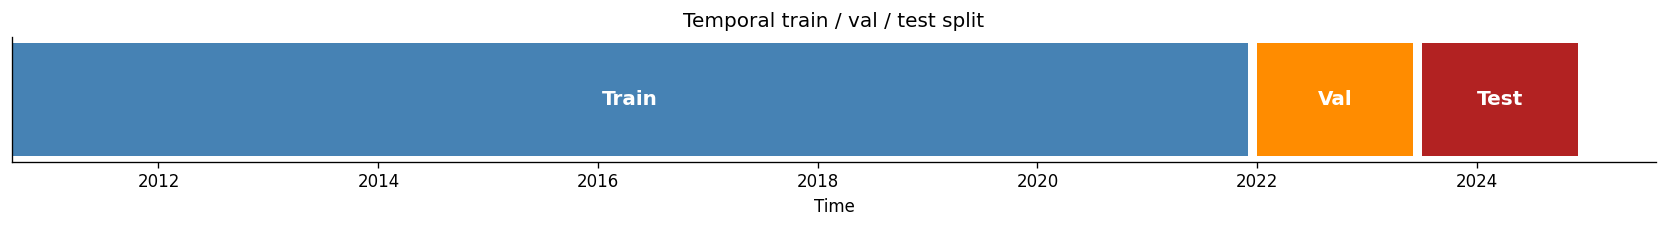

In [10]:
split_periods = [
    ('Train', '2010-09', '2021-12', 'steelblue'),
    ('Val',   '2022-01', '2023-06', 'darkorange'),
    ('Test',  '2023-07', '2024-12', 'firebrick'),
]

fig, ax = plt.subplots(figsize=(14, 2))
for label, start, end, color in split_periods:
    s = pd.to_datetime(start)
    e = pd.to_datetime(end)
    ax.barh(0, (e - s).days, left=s, height=0.5, color=color)
    ax.text(s + (e - s) / 2, 0, label, ha='center', va='center', color='white', fontweight='bold', fontsize=12)

ax.set_yticks([])
ax.set_xlabel('Time')
ax.set_title('Temporal train / val / test split')
plt.tight_layout()
plt.show()

---
## 3. Model — LightGBM Two-Stage Horizon Model

### 3.1 Architecture

A **sequential** set of 12 two-stage models — one per forecast horizon (`h1`–`h12`):

```
For horizon h_i:
  Stage 1  LGBMClassifier  →  P(harvest > 0)  [threshold tuned per F1 on val]
  Stage 2  LGBMRegressor   →  magnitude in log1p space  [Huber loss, non-zero rows only]
  Output   (P >= threshold) * max(reg_pred, 0)  [soft-blend below threshold]

  Input for h_i  =  base features + pred_h1 + ... + pred_h(i-1)
```

Key design choices:
- **Huber loss** on the regressor: robust to large-harvest outliers that inflate RMSE.
- **`scale_pos_weight`**: upweights the rare non-zero class proportionally.
- **Threshold search**: F1 maximisation on the validation set (not a fixed 0.5).
- **Prediction chaining with noise**: training-time Gaussian noise (σ = 15% of pred std) on chained predictions to prevent the chain from overfitting.

In [11]:
models = joblib.load('models/lgb_models.pkl')
print('Loaded horizons:', list(models.keys()))

df_meta = pd.DataFrame({
    'horizon':       list(models.keys()),
    'clf_threshold': [models[h]['threshold'] for h in models],
    'n_features':    [len(models[h]['feature_cols']) for h in models],
})
print(df_meta.to_string(index=False))

Loaded horizons: ['h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'h7', 'h8', 'h9', 'h10', 'h11', 'h12']
horizon  clf_threshold  n_features
     h1           0.70         326
     h2           0.67         327
     h3           0.68         328
     h4           0.66         329
     h5           0.65         330
     h6           0.63         331
     h7           0.62         332
     h8           0.64         333
     h9           0.59         334
    h10           0.63         335
    h11           0.60         336
    h12           0.57         337


### 3.2 Test Set Metrics

In [12]:
from models.model import add_derived_features, sanitize_columns
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error,
                              f1_score, precision_score, recall_score)

POSSIBLE_KEYS = ['ggo', 'odsek', 'odsek_id', 'leto_mesec']
DROP_COLS     = ['datum', 'leto']
TARGET_COLS   = [f'h{h}' for h in range(1, 13)]

test_x = pd.read_csv('data/processed/splits/test.csv', low_memory=False)
target = pd.read_csv('data/processed/target.csv', low_memory=False)

id_cols   = [c for c in POSSIBLE_KEYS if c in test_x.columns]
drop_cols = [c for c in DROP_COLS + TARGET_COLS if c in test_x.columns]
feat_cols = [c for c in test_x.columns if c not in set(id_cols + drop_cols)]

id_df  = test_x[id_cols].reset_index(drop=True)
X_base = test_x[feat_cols].fillna(0).reset_index(drop=True)
X_base = sanitize_columns(X_base)
X_base = add_derived_features(X_base)

keys = sorted(set(id_df.columns) & set(target.columns) & set(POSSIBLE_KEYS))
id_pos = id_df.copy(); id_pos['_pos'] = np.arange(len(id_df))
matched = id_pos.merge(target[keys + TARGET_COLS], on=keys, how='inner')
row_idx  = matched['_pos'].values
y_true_raw = matched[TARGET_COLS].values.astype(float)

# Sequential inference
X_aug = X_base.copy()
preds = np.zeros((len(X_base), 12))
for i, col in enumerate(TARGET_COLS):
    m      = models[col]
    fc     = m['feature_cols']
    thresh = m['threshold']
    for f in fc:
        if f not in X_aug.columns:
            X_aug[f] = 0.0
    clf_prob = m['clf'].predict_proba(X_aug[fc])[:, 1]
    reg_pred = np.maximum(m['reg'].predict(X_aug[fc]), 0.0)
    weight   = np.where(clf_prob >= thresh, 1.0, clf_prob / thresh)
    preds[:, i] = weight * reg_pred
    if i < 11:
        X_aug = X_aug.copy()
        X_aug[f'pred_{col}'] = preds[:, i]

preds_ev = preds[row_idx]
valid    = ~np.isnan(y_true_raw).any(axis=1)
y_true_raw = y_true_raw[valid]
preds_ev   = preds_ev[valid]

LOG_CLIP_MAX = 15.0  # safe expm1 upper bound in log1p space
nonzero_truth = y_true_raw[y_true_raw > 0]
q99_truth = float(np.nanpercentile(nonzero_truth, 99)) if nonzero_truth.size else 0.0

target_is_raw_m3 = q99_truth > LOG_CLIP_MAX
if target_is_raw_m3:
    # target.csv is already in m3; do not exponentiate it again
    y_true_m3 = np.maximum(y_true_raw, 0)
    y_true_log = np.log1p(y_true_m3)
    n_true_clipped = 0
else:
    n_true_clipped = int((y_true_raw > LOG_CLIP_MAX).sum())
    y_true_log = np.clip(y_true_raw, a_min=0, a_max=LOG_CLIP_MAX)
    y_true_m3 = np.expm1(y_true_log)

n_pred_clipped = int((preds_ev > LOG_CLIP_MAX).sum())
preds_ev = np.clip(preds_ev, a_min=0, a_max=LOG_CLIP_MAX)
preds_m3 = np.expm1(preds_ev)

# Keep only finite rows after conversion.
fin_mask = np.isfinite(y_true_m3).all(axis=1) & np.isfinite(preds_m3).all(axis=1)
y_true_m3 = y_true_m3[fin_mask]
preds_m3  = preds_m3[fin_mask]
y_true_log = y_true_log[fin_mask]
preds_ev = preds_ev[fin_mask]

preds_m3[preds_m3 < 5] = 0.0
lm_vals = matched['leto_mesec'].values[valid][fin_mask]  # for monthly plot

# Keep aligned arrays for downstream plotting cells.
preds_ev_fin   = preds_ev
y_true_log_fin = y_true_log
preds_m3_fin   = preds_m3
y_true_m3_fin  = y_true_m3

scale_label = 'raw m3' if target_is_raw_m3 else 'log1p'
print(f'Target scale detected: {scale_label} (99th percentile non-zero = {q99_truth:.2f})')
print(f'Matched test rows: {len(y_true_m3):,}  (non-finite rows dropped: {(~fin_mask).sum()})')
print(f'Values clipped above {LOG_CLIP_MAX:g} log1p: true={n_true_clipped:,}, pred={n_pred_clipped:,}')

Target scale detected: raw m3 (99th percentile non-zero = 315.48)
Matched test rows: 135,133  (non-finite rows dropped: 0)
Values clipped above 15 log1p: true=0, pred=0


In [13]:
rows = []
for i, col in enumerate(TARGET_COLS):
    yt = y_true_m3[:, i]; yp = preds_m3[:, i]
    nz = yt > 0
    rows.append(dict(
        horizon   = col,
        MAE_all   = mean_absolute_error(yt, yp),
        MAE_nz    = mean_absolute_error(yt[nz], yp[nz]) if nz.sum() else np.nan,
        RMSE      = root_mean_squared_error(yt, yp),
        Bias      = float(np.mean(yp - yt)),
        F1        = f1_score((yt>0).astype(int), (yp>0).astype(int), zero_division=0),
        Precision = precision_score((yt>0).astype(int), (yp>0).astype(int), zero_division=0),
        Recall    = recall_score((yt>0).astype(int), (yp>0).astype(int), zero_division=0),
    ))

metrics_df = pd.DataFrame(rows)
print('Test metrics (m³ space):')
display(metrics_df.round(3))

Test metrics (m³ space):


,horizon,MAE_all,MAE_nz,RMSE,Bias,F1,Precision,Recall
0,h1,16.564,37.523,32.130,9.703,0.257,0.152,0.844
1,h2,26.337,39.808,39.927,21.059,0.226,0.128,0.971
2,h3,23.908,40.682,39.500,18.802,0.229,0.130,0.937
3,h4,37.097,47.780,52.610,33.429,0.222,0.126,0.917
4,h5,36.982,54.790,57.880,33.377,0.223,0.128,0.883
5,h6,51.832,70.448,77.916,49.123,0.203,0.114,0.950
6,h7,67.754,75.881,90.252,65.408,0.196,0.109,0.982
7,h8,81.844,81.589,97.687,79.779,0.195,0.108,1.000
8,h9,92.010,90.953,108.927,90.010,0.198,0.110,1.000
9,h10,46.977,49.052,58.338,42.660,0.204,0.114,0.991


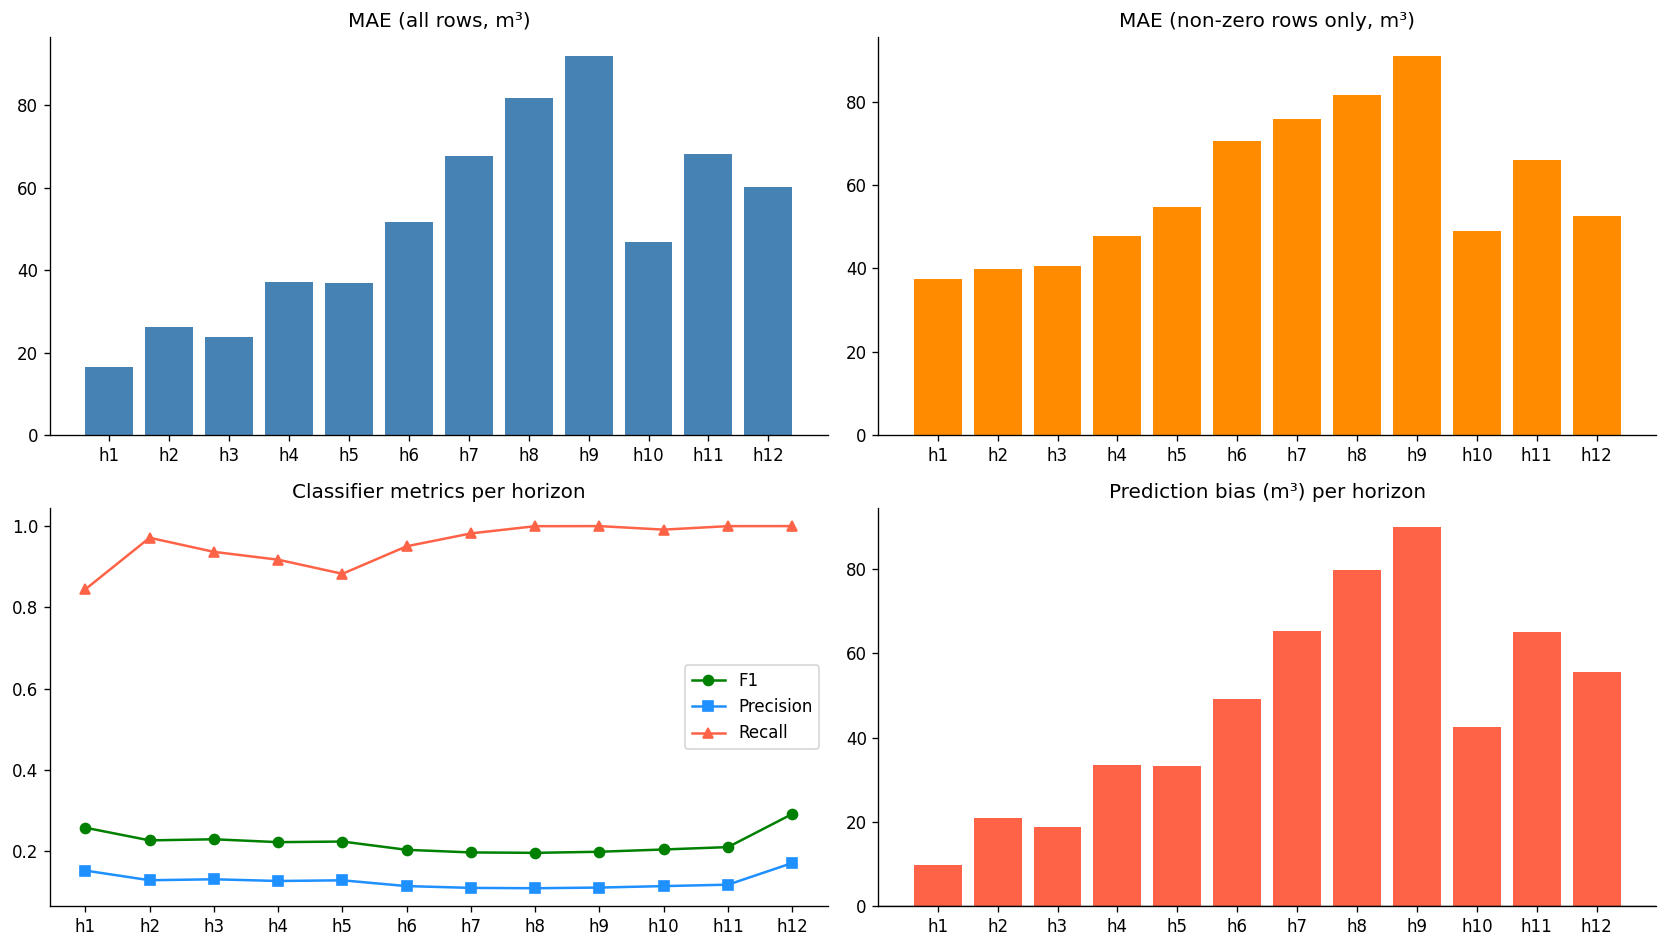

In [14]:
x = np.arange(12)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].bar(x, metrics_df['MAE_all'], color='steelblue')
axes[0,0].set_title('MAE (all rows, m³)')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(TARGET_COLS)

axes[0,1].bar(x, metrics_df['MAE_nz'], color='darkorange')
axes[0,1].set_title('MAE (non-zero rows only, m³)')
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(TARGET_COLS)

axes[1,0].plot(x, metrics_df['F1'],        marker='o', label='F1',        color='green')
axes[1,0].plot(x, metrics_df['Precision'], marker='s', label='Precision', color='dodgerblue')
axes[1,0].plot(x, metrics_df['Recall'],    marker='^', label='Recall',    color='tomato')
axes[1,0].set_title('Classifier metrics per horizon')
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(TARGET_COLS)
axes[1,0].legend()

colors = ['tomato' if b > 0 else 'steelblue' for b in metrics_df['Bias']]
axes[1,1].bar(x, metrics_df['Bias'], color=colors)
axes[1,1].axhline(0, color='black', linewidth=0.8)
axes[1,1].set_title('Prediction bias (m³) per horizon')
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(TARGET_COLS)

plt.tight_layout()
plt.show()

### 3.3 Feature Importance

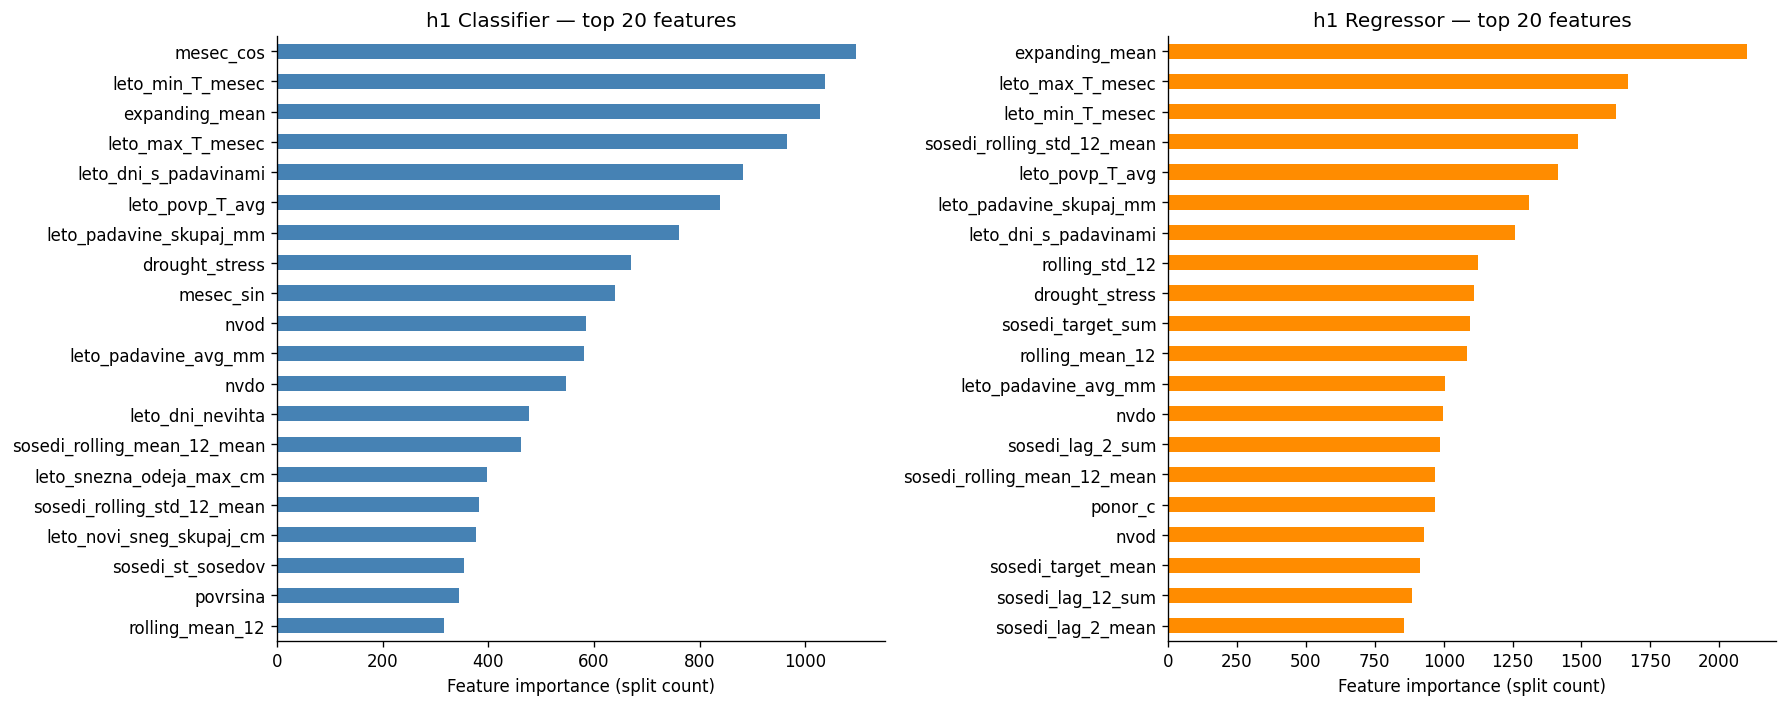

In [15]:
def plot_feature_importance(model_dict, horizon='h1', top_n=20):
    m  = model_dict[horizon]
    fc = m['feature_cols']
    has_clf = 'clf' in m

    if has_clf:
        clf_imp = pd.Series(m['clf'].feature_importances_, index=fc).sort_values(ascending=False).head(top_n)
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        clf_imp[::-1].plot.barh(ax=axes[0], color='steelblue')
        axes[0].set_title(f'{horizon} Classifier — top {top_n} features')
        axes[0].set_xlabel('Feature importance (split count)')
        reg_ax = axes[1]
    else:
        fig, axes = plt.subplots(1, 1, figsize=(8, 6))
        reg_ax = axes

    reg_imp = pd.Series(m['reg'].feature_importances_, index=fc).sort_values(ascending=False).head(top_n)
    reg_imp[::-1].plot.barh(ax=reg_ax, color='darkorange')
    reg_ax.set_title(f'{horizon} Regressor — top {top_n} features')
    reg_ax.set_xlabel('Feature importance (split count)')

    plt.tight_layout()
    plt.show()

plot_feature_importance(models, 'h1')

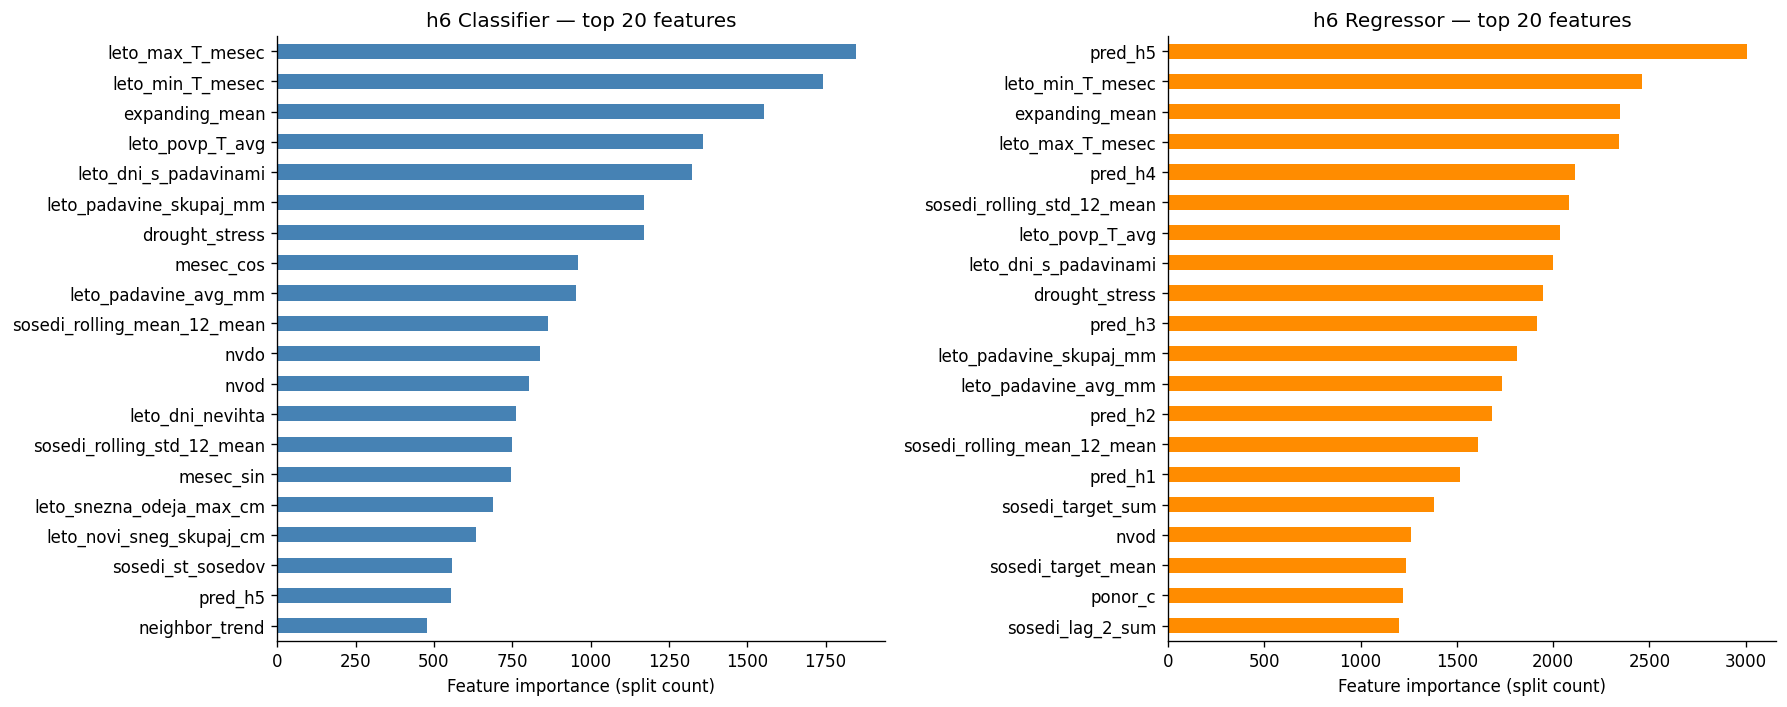

In [16]:
plot_feature_importance(models, 'h6')

### 3.4 Prediction Plots

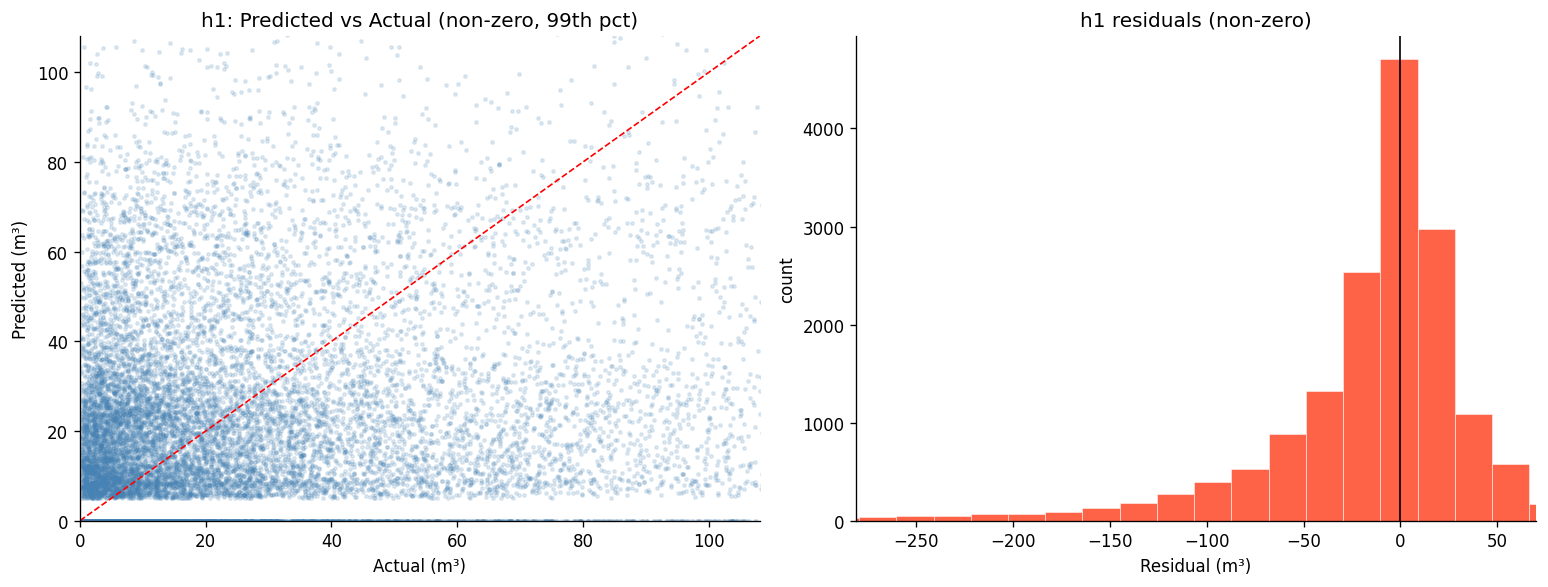

In [17]:
yt_h1 = y_true_m3[:, 0]
yp_h1 = preds_m3[:, 0]
nz_fin = (yt_h1 > 0) & np.isfinite(yt_h1) & np.isfinite(yp_h1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = min(np.percentile(yt_h1[nz_fin], 99), np.percentile(yp_h1[nz_fin], 99)) * 1.1
axes[0].scatter(yt_h1[nz_fin], yp_h1[nz_fin], alpha=0.15, s=4, color='steelblue')
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1)
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel('Actual (m³)'); axes[0].set_ylabel('Predicted (m³)')
axes[0].set_title('h1: Predicted vs Actual (non-zero, 99th pct)')

residuals = yp_h1[nz_fin] - yt_h1[nz_fin]
axes[1].hist(residuals, bins=80, color='tomato', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Residual (m³)'); axes[1].set_ylabel('count')
axes[1].set_title('h1 residuals (non-zero)')
axes[1].set_xlim(np.percentile(residuals, 1), np.percentile(residuals, 99))

plt.tight_layout()
plt.show()


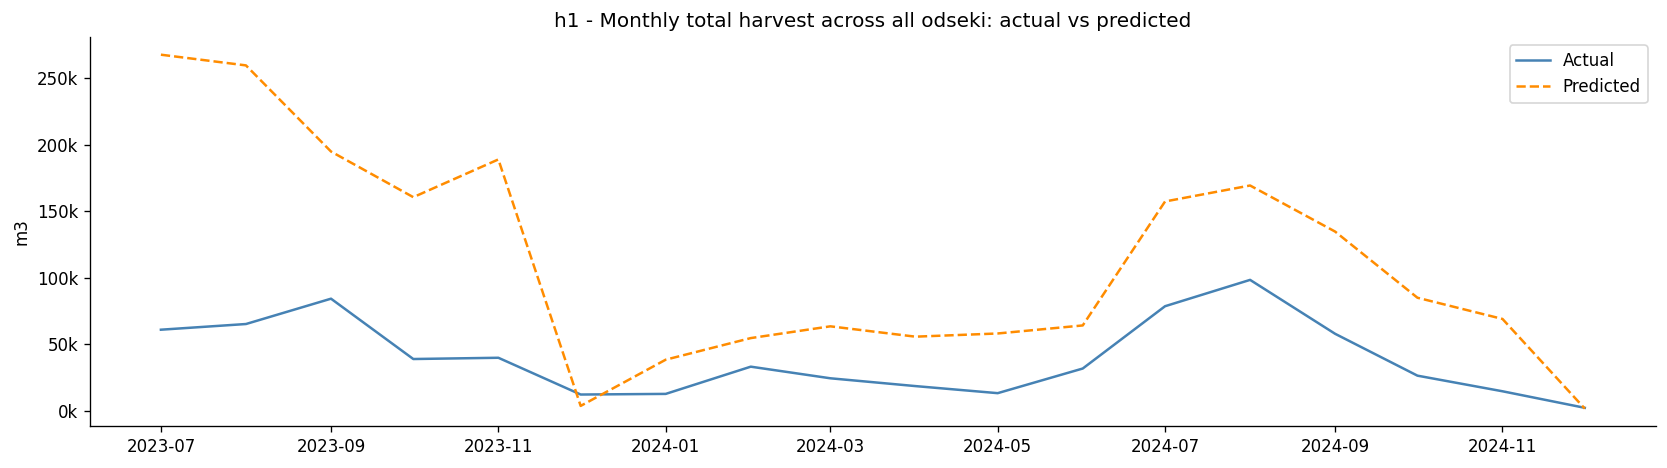

In [18]:
# Aggregate monthly totals in m3 space using aligned evaluation arrays
plot_df = pd.DataFrame({
    'leto_mesec': lm_vals,
    'actual_h1_m3': y_true_m3_fin[:, 0],
    'pred_h1_m3': preds_m3_fin[:, 0],
})
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

monthly_pred = plot_df.groupby('leto_mesec')['pred_h1_m3'].sum()
monthly_true = plot_df.groupby('leto_mesec')['actual_h1_m3'].sum()

combined = pd.DataFrame({'actual': monthly_true, 'predicted': monthly_pred}).dropna()
combined.index = pd.to_datetime(combined.index)
combined = combined.sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(combined.index, combined['actual'],    color='steelblue',  label='Actual',    linewidth=1.5)
ax.plot(combined.index, combined['predicted'], color='darkorange', label='Predicted', linewidth=1.5, linestyle='--')
ax.set_title('h1 - Monthly total harvest across all odseki: actual vs predicted')
ax.set_ylabel('m3')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k' if x < 1e6 else f'{x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()


---
## 4. Synthetic Data

### 4.1 Generation Model

Because real bark beetle population counts are not available, a **physics-inspired simulation** generates synthetic monthly bark beetle populations per `(ggo, odsek)` over 2007–2025.

The model integrates seven ecological mechanisms in sequence at each time step:

| Step | Mechanism | Formula |
|------|-----------|--------|
| 1 | **Temperature suitability** | Gaussian response on mean(avg, min, max) T, optimum 22 °C, width 10 |
| 2 | **Growth rate** | `r_t = r_base × temp_suit × seasonal_sin × outbreak_cycle` |
| 3 | **Logistic growth** | `ΔB = r_t × B × (1 – B/K)` , K = 50 000 |
| 4 | **Predator (harvest) effect** | `B -= α × (0.6 × wood_{t-1} + 0.4 × wood_{t-2}) × B` |
| 5 | **Spatial diffusion** | `B += γ × w × (neighbor_B – B)` via sparse row-normalised weight matrix |
| 6 | **Winter mortality** | `B *= (1 – 0.2)` when avg T < 0 °C |
| 7 | **Gaussian noise** | `B += N(0, 200)` |

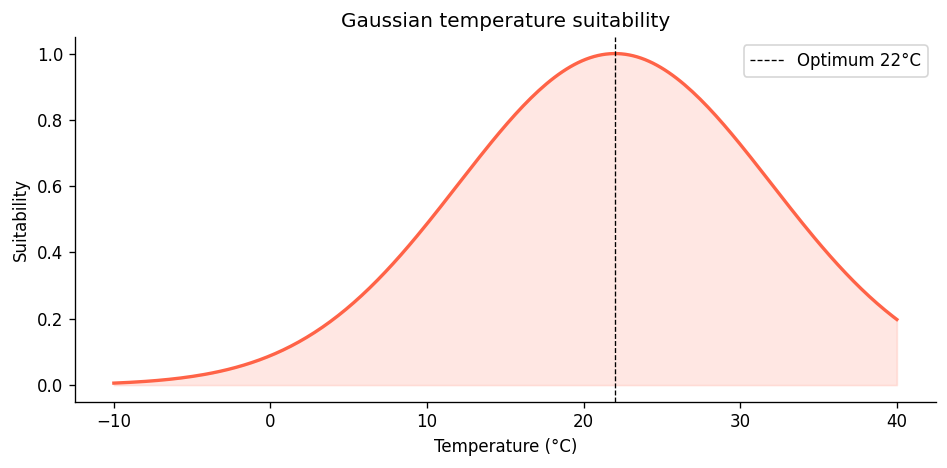

In [19]:
# Temperature suitability function
T_range = np.linspace(-10, 40, 200)
suitability = np.exp(-((T_range - 22)**2) / (2 * 10**2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_range, suitability, color='tomato', linewidth=2)
ax.axvline(22, color='black', linewidth=0.8, linestyle='--', label='Optimum 22°C')
ax.fill_between(T_range, suitability, alpha=0.15, color='tomato')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Suitability')
ax.set_title('Gaussian temperature suitability')
ax.legend()
plt.tight_layout()
plt.show()

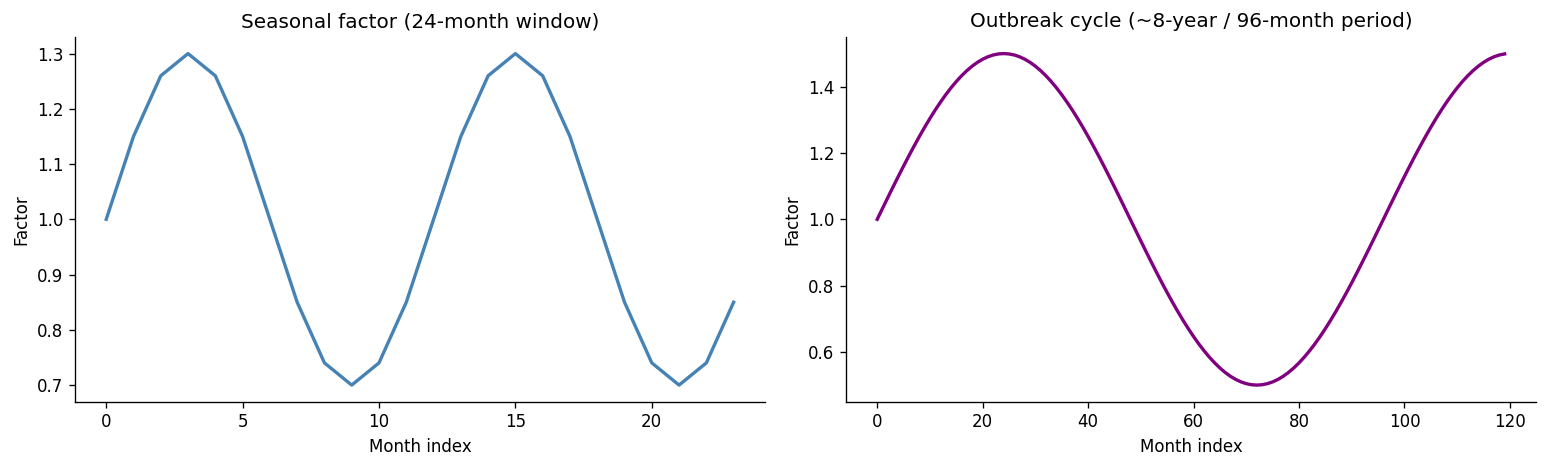

In [20]:
# Seasonal and outbreak cycles
t = np.arange(0, 120)
seasonal = 1 + 0.3 * np.sin(2 * np.pi * (t % 12) / 12)
outbreak = 1 + 0.5 * np.sin(2 * np.pi * t / 96)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t[:24], seasonal[:24], color='steelblue', linewidth=2)
axes[0].set_title('Seasonal factor (24-month window)')
axes[0].set_xlabel('Month index'); axes[0].set_ylabel('Factor')

axes[1].plot(t, outbreak, color='purple', linewidth=2)
axes[1].set_title('Outbreak cycle (~8-year / 96-month period)')
axes[1].set_xlabel('Month index'); axes[1].set_ylabel('Factor')

plt.tight_layout()
plt.show()

### 4.2 Synthetic Population Plots

In [21]:
synth_pop = pd.read_csv('data/synthetic/bark_beetle_population.csv', low_memory=False)
print(f'Synthetic population — shape: {synth_pop.shape}')
display(synth_pop.head(5))
print('\nDescriptive stats:')
print(synth_pop['bark_beetle_count'].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(1))

Synthetic population — shape: (12141912, 4)


,ggo,odsek,leto_mesec,bark_beetle_count
0,1,01001A,2007-01,652
1,1,01001A,2007-02,0
2,1,01001A,2007-03,215
3,1,01001A,2007-04,702
4,1,01001A,2007-05,1474



Descriptive stats:
count    12141912.0
mean          523.3
std           830.5
min             0.0
1%              0.0
25%            30.0
50%           243.0
75%           679.0
99%          3729.0
max         35880.0
Name: bark_beetle_count, dtype: float64


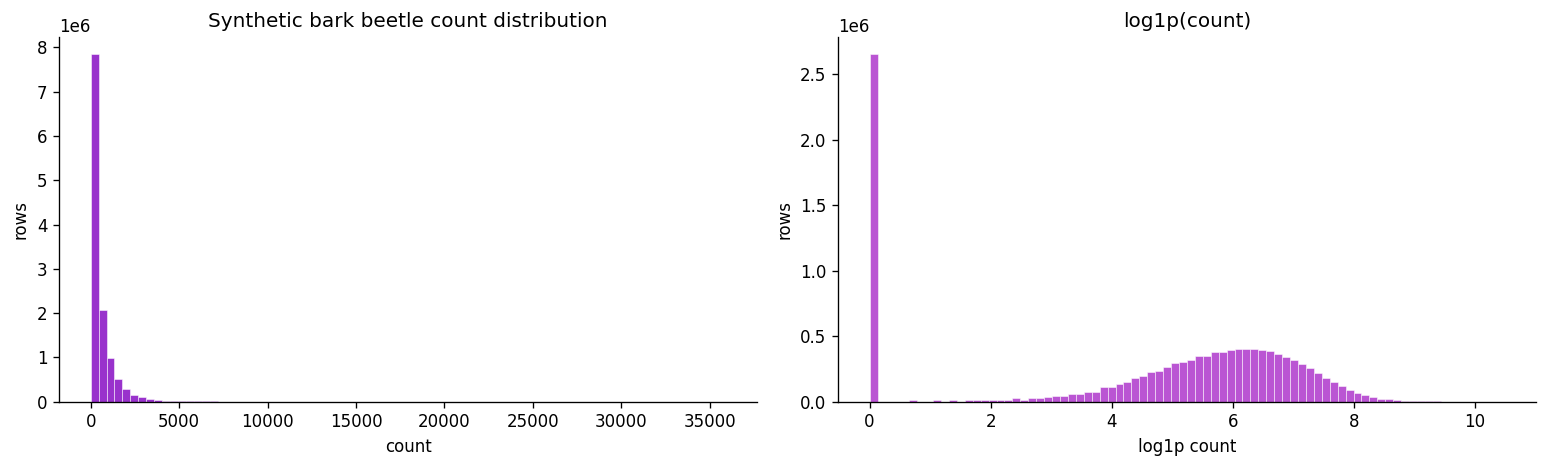

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(synth_pop['bark_beetle_count'], bins=80, color='darkorchid', edgecolor='white', linewidth=0.3)
axes[0].set_title('Synthetic bark beetle count distribution')
axes[0].set_xlabel('count'); axes[0].set_ylabel('rows')

axes[1].hist(np.log1p(synth_pop['bark_beetle_count']), bins=80, color='mediumorchid', edgecolor='white', linewidth=0.3)
axes[1].set_title('log1p(count)')
axes[1].set_xlabel('log1p count'); axes[1].set_ylabel('rows')

plt.tight_layout()
plt.show()

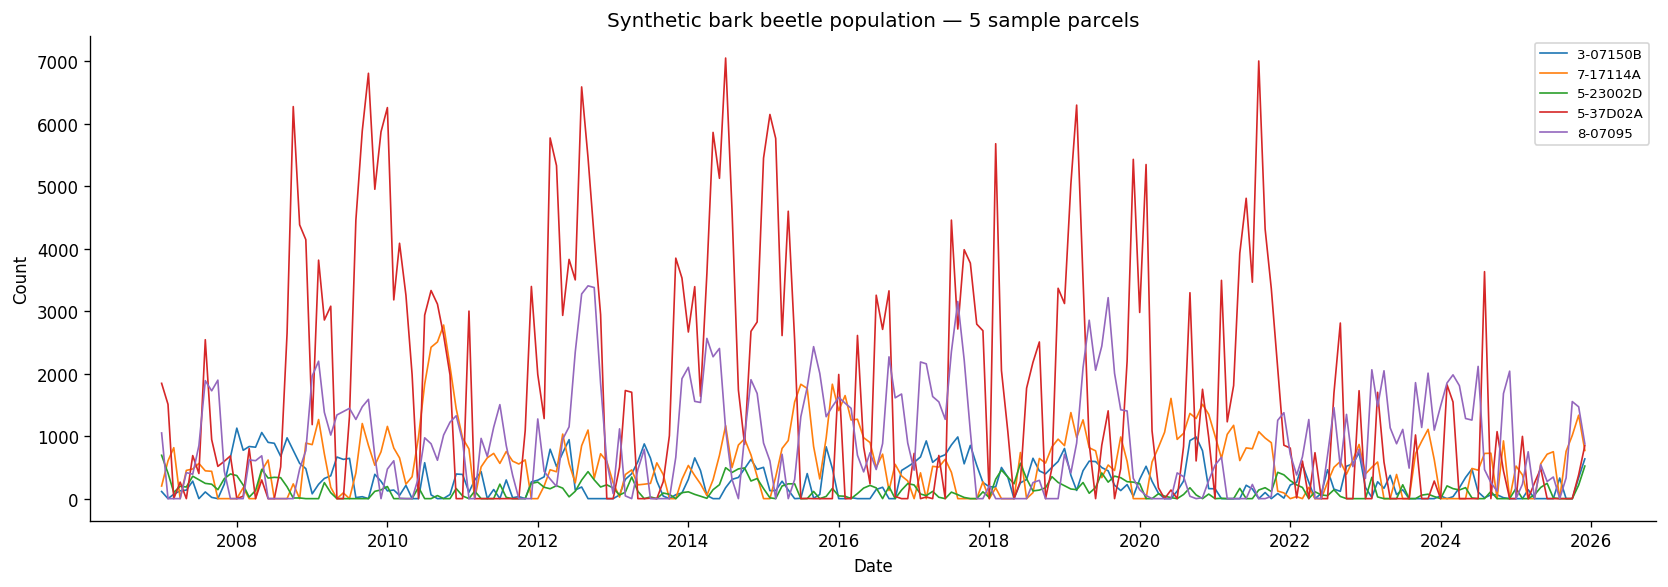

In [23]:
sample_parcels = synth_pop.groupby(['ggo','odsek']).size().reset_index()[['ggo','odsek']].sample(5, random_state=42)

fig, ax = plt.subplots(figsize=(14, 5))
for _, row in sample_parcels.iterrows():
    sub = synth_pop[(synth_pop['ggo'] == row['ggo']) & (synth_pop['odsek'] == row['odsek'])].copy()
    sub['date'] = pd.to_datetime(sub['leto_mesec'])
    sub = sub.sort_values('date')
    ax.plot(sub['date'], sub['bark_beetle_count'], linewidth=1, label=f"{row['ggo']}-{row['odsek']}")

ax.set_title('Synthetic bark beetle population — 5 sample parcels')
ax.set_xlabel('Date'); ax.set_ylabel('Count')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

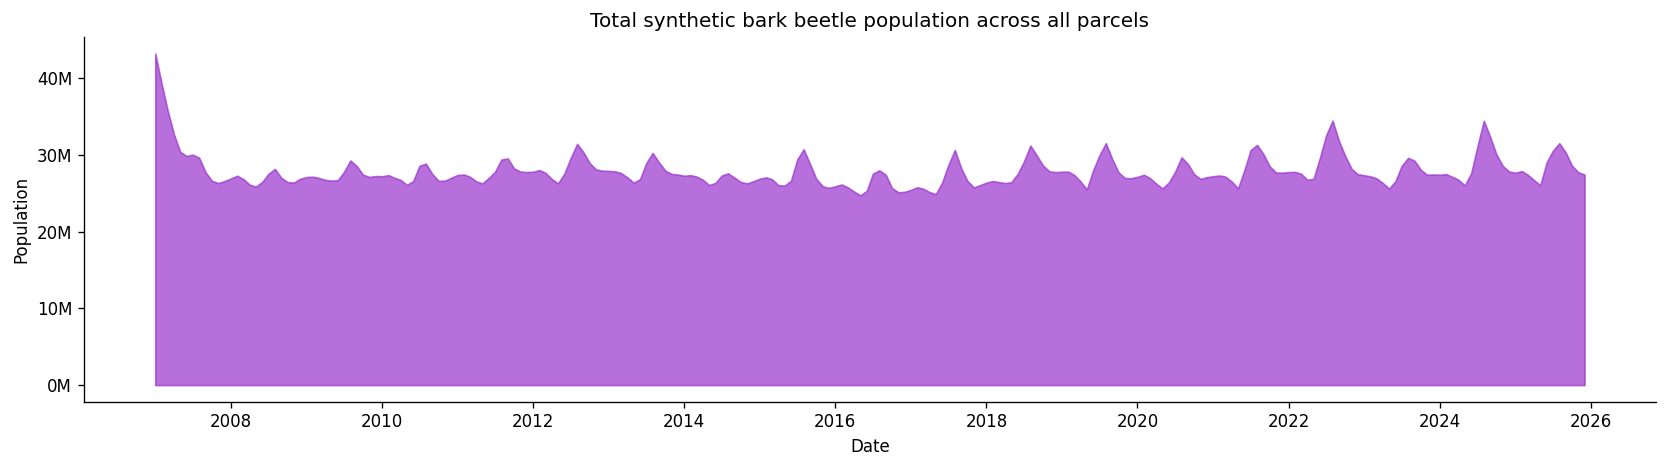

In [24]:
monthly_synth = synth_pop.groupby('leto_mesec')['bark_beetle_count'].sum().reset_index()
monthly_synth['date'] = pd.to_datetime(monthly_synth['leto_mesec'])
monthly_synth = monthly_synth.sort_values('date')

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly_synth['date'], monthly_synth['bark_beetle_count'], alpha=0.7, color='darkorchid')
ax.set_title('Total synthetic bark beetle population across all parcels')
ax.set_xlabel('Date'); ax.set_ylabel('Population')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

---
## 5. Synthetic Data Model — LightGBM on Simulated Population

The same two-stage sequential LightGBM architecture is retrained on synthetic data.  
The synthetic target (`synthetic_target.csv`) contains 12 forward horizons of log1p bark beetle population,  
analogous to the harvest-volume targets in the real model.

In [25]:
models_synth = joblib.load('models/lgb_models_synthetic.pkl')
print('Loaded synthetic horizons:', list(models_synth.keys()))

df_meta_synth = pd.DataFrame({
    'horizon':    list(models_synth.keys()),
    'n_features': [len(models_synth[h]['feature_cols']) for h in models_synth],
})
print(df_meta_synth.to_string(index=False))

Loaded synthetic horizons: ['h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'h7', 'h8', 'h9', 'h10', 'h11', 'h12']
horizon  n_features
     h1          36
     h2          37
     h3          38
     h4          39
     h5          40
     h6          41
     h7          42
     h8          43
     h9          44
    h10          45
    h11          46
    h12          47


### 5.1 Test Set Metrics (Synthetic)

In [26]:
SYNTH_DATA_DIR    = Path('data/synthetic/splits')
SYNTH_TARGET_PATH = Path('data/synthetic/synthetic_target.csv')

test_synth_x = pd.read_csv(SYNTH_DATA_DIR / 'test_synthetic.csv', low_memory=False)
target_synth = pd.read_csv(SYNTH_TARGET_PATH, low_memory=False)
print(f'Synthetic test split - {len(test_synth_x):,} rows x {test_synth_x.shape[1]} columns')

id_cols_s   = [c for c in POSSIBLE_KEYS if c in test_synth_x.columns]
drop_cols_s = [c for c in DROP_COLS + TARGET_COLS if c in test_synth_x.columns]
feat_cols_s = [c for c in test_synth_x.columns if c not in set(id_cols_s + drop_cols_s)]

id_df_s  = test_synth_x[id_cols_s].reset_index(drop=True)
X_base_s = test_synth_x[feat_cols_s].fillna(0).reset_index(drop=True)
X_base_s = sanitize_columns(X_base_s)
X_base_s = add_derived_features(X_base_s)

keys_s   = sorted(set(id_df_s.columns) & set(target_synth.columns) & set(POSSIBLE_KEYS))
id_pos_s = id_df_s.copy(); id_pos_s['_pos'] = np.arange(len(id_df_s))
matched_s    = id_pos_s.merge(target_synth[keys_s + TARGET_COLS], on=keys_s, how='inner')
row_idx_s    = matched_s['_pos'].values
y_true_raw_s = matched_s[TARGET_COLS].values.astype(float)

# Synthetic model is a single-stage regressor (no classifier / threshold)
X_aug_s = X_base_s.copy()
preds_s = np.zeros((len(X_base_s), 12))
for i, col in enumerate(TARGET_COLS):
    m  = models_synth[col]
    fc = m['feature_cols']
    for f in fc:
        if f not in X_aug_s.columns:
            X_aug_s[f] = 0.0
    preds_s[:, i] = np.maximum(m['reg'].predict(X_aug_s[fc]), 0.0)
    if i < 11:
        X_aug_s = X_aug_s.copy()
        X_aug_s[f'pred_{col}'] = preds_s[:, i]

preds_ev_s = preds_s[row_idx_s]
valid_s    = ~np.isnan(y_true_raw_s).any(axis=1)
y_true_raw_s = y_true_raw_s[valid_s]
preds_ev_s   = preds_ev_s[valid_s]

LOG_CLIP_MAX_SYNTH = 15.0
nonzero_truth_s = y_true_raw_s[y_true_raw_s > 0]
q99_truth_s = float(np.nanpercentile(nonzero_truth_s, 99)) if nonzero_truth_s.size else 0.0

target_is_raw_s = q99_truth_s > LOG_CLIP_MAX_SYNTH
if target_is_raw_s:
    y_true_pop = np.maximum(y_true_raw_s, 0)
    y_true_log_s = np.log1p(y_true_pop)
    n_true_clipped_s = 0
else:
    n_true_clipped_s = int((y_true_raw_s > LOG_CLIP_MAX_SYNTH).sum())
    y_true_log_s = np.clip(y_true_raw_s, a_min=0, a_max=LOG_CLIP_MAX_SYNTH)
    y_true_pop = np.expm1(y_true_log_s)

n_pred_clipped_s = int((preds_ev_s > LOG_CLIP_MAX_SYNTH).sum())
preds_ev_s = np.clip(preds_ev_s, a_min=0, a_max=LOG_CLIP_MAX_SYNTH)
preds_pop  = np.expm1(preds_ev_s)

fin_mask_s = np.isfinite(y_true_pop).all(axis=1) & np.isfinite(preds_pop).all(axis=1)
y_true_pop = y_true_pop[fin_mask_s]
preds_pop  = preds_pop[fin_mask_s]
y_true_log_s = y_true_log_s[fin_mask_s]
preds_ev_s = preds_ev_s[fin_mask_s]
preds_pop[preds_pop < 5] = 0.0

scale_label_s = 'raw count' if target_is_raw_s else 'log1p'
print(f'Synthetic target scale detected: {scale_label_s} (99th percentile non-zero = {q99_truth_s:.2f})')
print(f'Matched synthetic test rows: {len(y_true_pop):,}  (non-finite rows dropped: {(~fin_mask_s).sum()})')
print(f'Values clipped above {LOG_CLIP_MAX_SYNTH:g} log1p: true={n_true_clipped_s:,}, pred={n_pred_clipped_s:,}')

Synthetic test split - 2,556,192 rows x 31 columns
Synthetic target scale detected: log1p (99th percentile non-zero = 8.33)
Matched synthetic test rows: 1,917,144  (non-finite rows dropped: 0)
Values clipped above 15 log1p: true=0, pred=0


In [27]:
rows_s = []
for i, col in enumerate(TARGET_COLS):
    yt = y_true_pop[:, i]; yp = preds_pop[:, i]
    nz = yt > 0
    rows_s.append(dict(
        horizon   = col,
        MAE_all   = mean_absolute_error(yt, yp),
        MAE_nz    = mean_absolute_error(yt[nz], yp[nz]) if nz.sum() else np.nan,
        RMSE      = root_mean_squared_error(yt, yp),
        Bias      = float(np.mean(yp - yt)),
        F1        = f1_score((yt>0).astype(int), (yp>0).astype(int), zero_division=0),
        Precision = precision_score((yt>0).astype(int), (yp>0).astype(int), zero_division=0),
        Recall    = recall_score((yt>0).astype(int), (yp>0).astype(int), zero_division=0),
    ))

metrics_df_s = pd.DataFrame(rows_s)
print('Synthetic test metrics (population space):')
display(metrics_df_s.round(3))

Synthetic test metrics (population space):


,horizon,MAE_all,MAE_nz,RMSE,Bias,F1,Precision,Recall
0,h1,525.546,667.631,986.561,-522.597,0.814,0.848,0.784
1,h2,524.125,664.218,985.589,-518.490,0.820,0.808,0.831
2,h3,518.986,654.963,979.603,-508.551,0.828,0.794,0.864
3,h4,510.558,639.584,968.030,-491.364,0.841,0.789,0.901
4,h5,497.634,615.048,947.746,-460.940,0.855,0.786,0.938
5,h6,489.596,597.428,930.773,-434.487,0.862,0.786,0.955
6,h7,482.908,579.617,911.604,-401.330,0.864,0.786,0.960
7,h8,480.197,562.182,893.866,-351.826,0.865,0.785,0.964
8,h9,483.308,552.600,888.304,-306.104,0.868,0.785,0.972
9,h10,476.776,551.393,886.061,-333.383,0.867,0.785,0.970


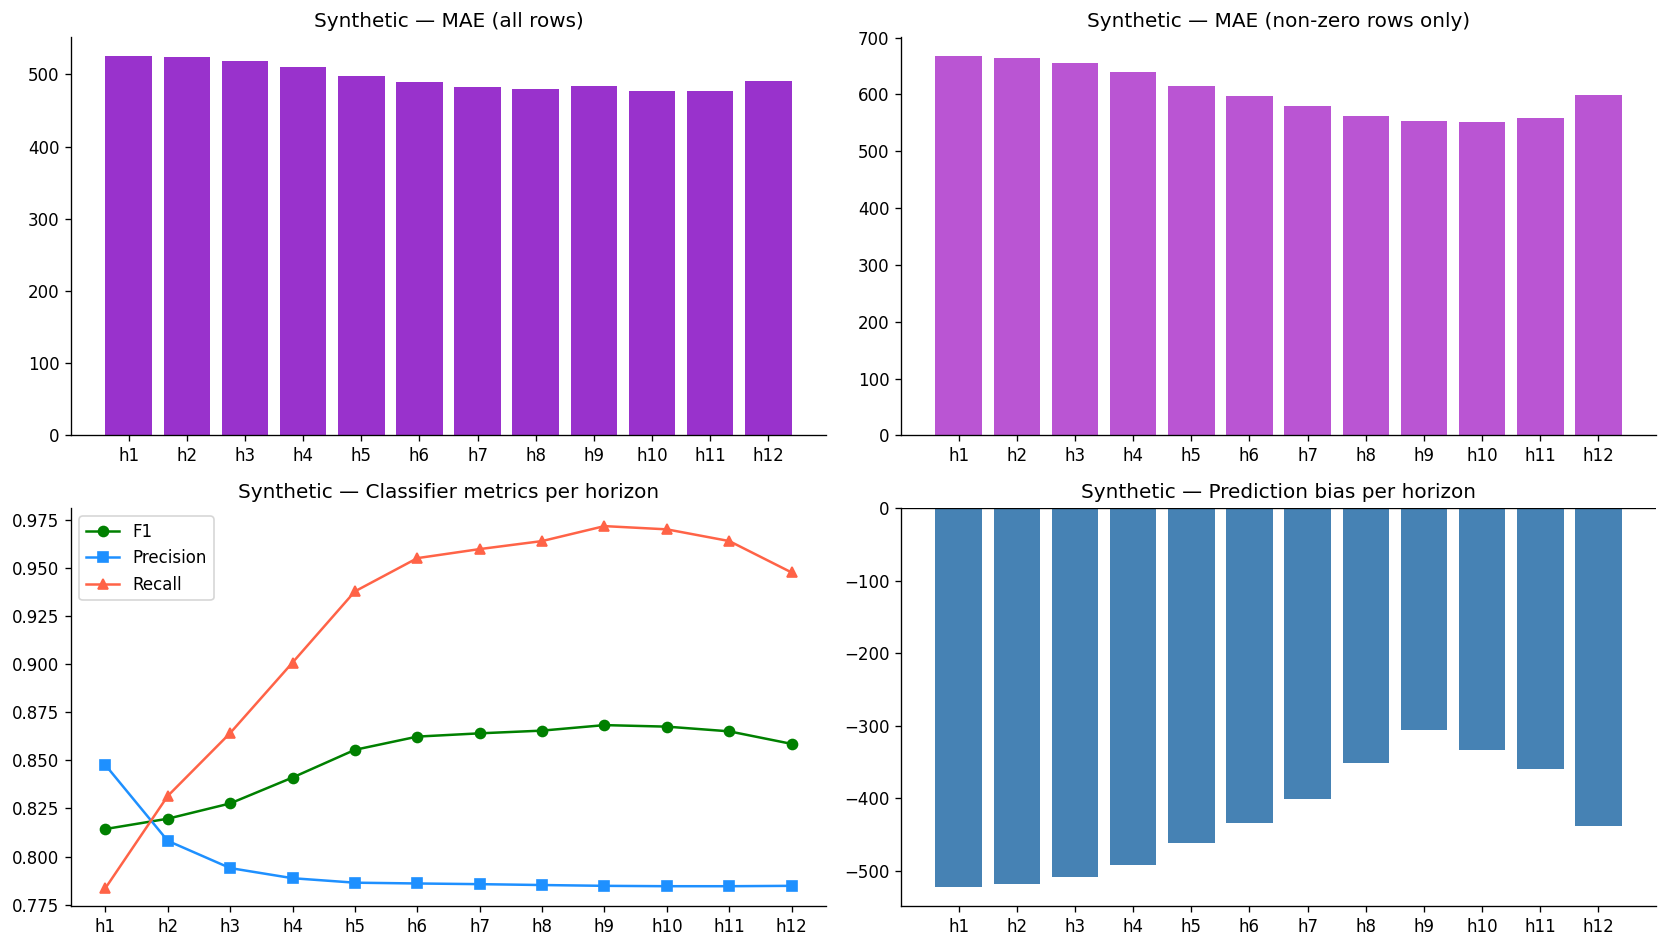

In [28]:
x = np.arange(12)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].bar(x, metrics_df_s['MAE_all'], color='darkorchid')
axes[0,0].set_title('Synthetic — MAE (all rows)')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(TARGET_COLS)

axes[0,1].bar(x, metrics_df_s['MAE_nz'], color='mediumorchid')
axes[0,1].set_title('Synthetic — MAE (non-zero rows only)')
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(TARGET_COLS)

axes[1,0].plot(x, metrics_df_s['F1'],        marker='o', label='F1',        color='green')
axes[1,0].plot(x, metrics_df_s['Precision'], marker='s', label='Precision', color='dodgerblue')
axes[1,0].plot(x, metrics_df_s['Recall'],    marker='^', label='Recall',    color='tomato')
axes[1,0].set_title('Synthetic — Classifier metrics per horizon')
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(TARGET_COLS)
axes[1,0].legend()

colors_s = ['tomato' if b > 0 else 'steelblue' for b in metrics_df_s['Bias']]
axes[1,1].bar(x, metrics_df_s['Bias'], color=colors_s)
axes[1,1].axhline(0, color='black', linewidth=0.8)
axes[1,1].set_title('Synthetic — Prediction bias per horizon')
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(TARGET_COLS)

plt.tight_layout()
plt.show()

### 5.2 Feature Importance (Synthetic)

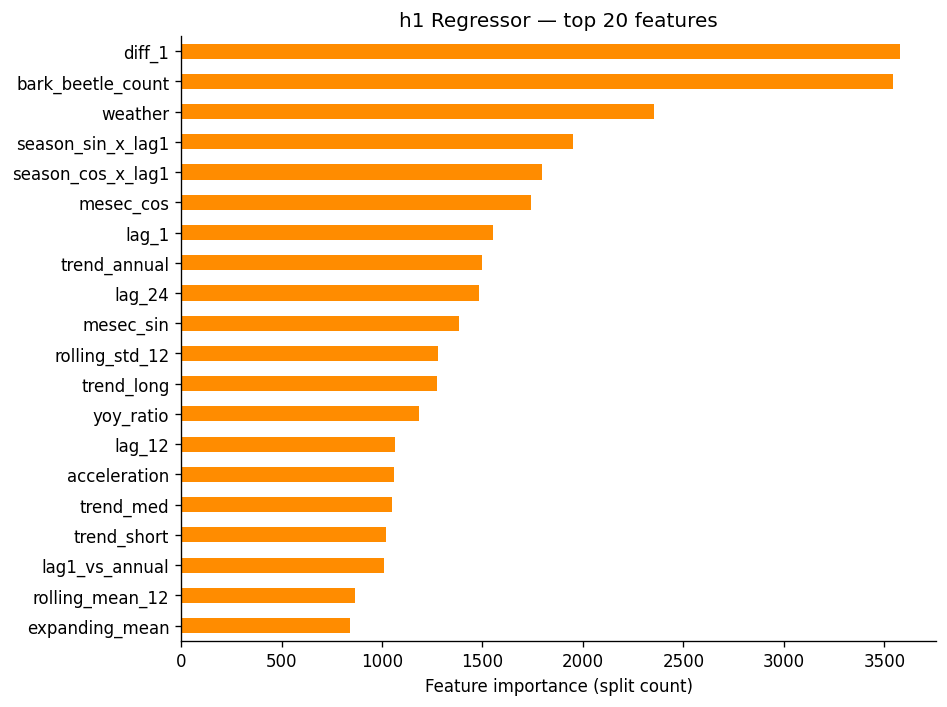

In [29]:
plot_feature_importance(models_synth, 'h1')

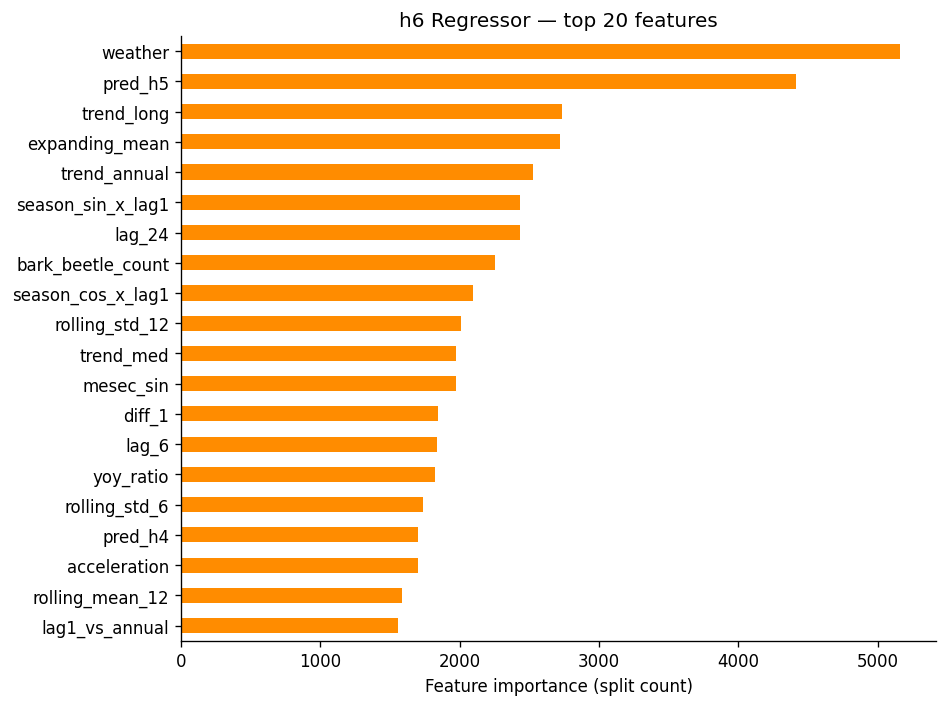

In [30]:
plot_feature_importance(models_synth, 'h6')

### 5.3 Prediction Plots (Synthetic)

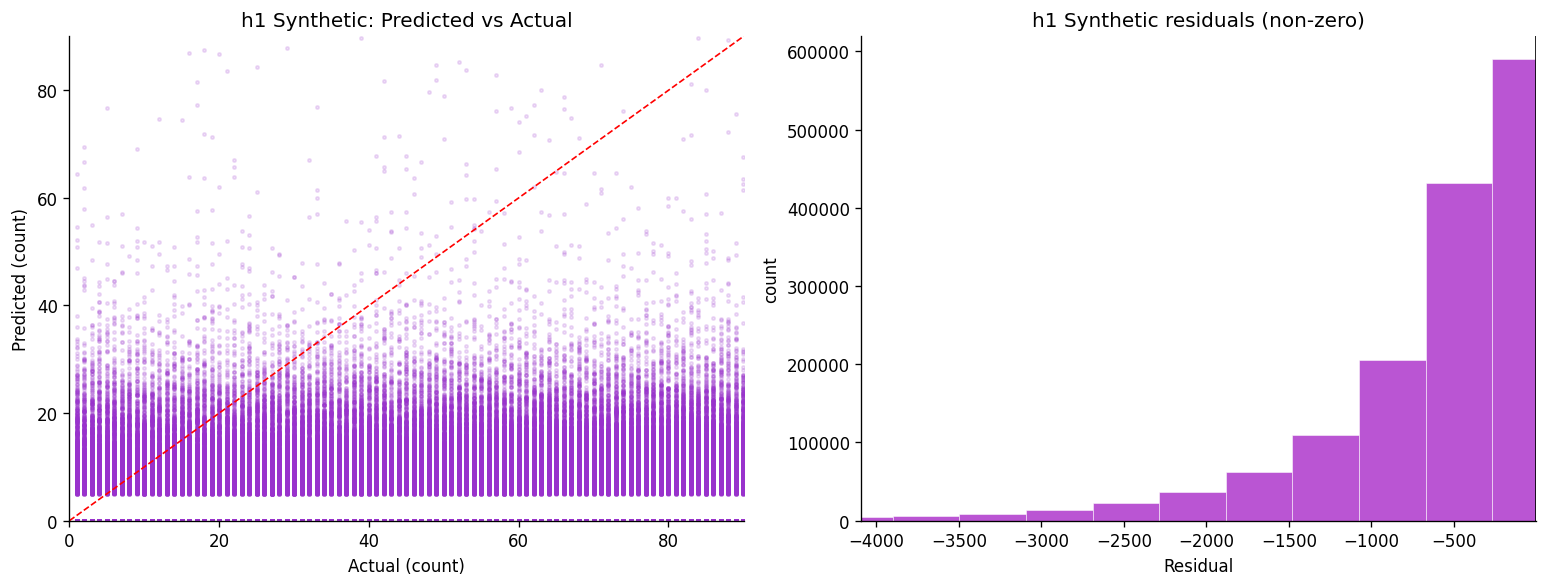

In [31]:
yt_h1_s  = y_true_pop[:, 0]
yp_h1_s  = preds_pop[:, 0]
nz_fin_s = (yt_h1_s > 0) & np.isfinite(yt_h1_s) & np.isfinite(yp_h1_s)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if nz_fin_s.sum() > 1:
    lim_s = min(np.percentile(yt_h1_s[nz_fin_s], 99), np.percentile(yp_h1_s[nz_fin_s], 99)) * 1.1
    axes[0].scatter(yt_h1_s[nz_fin_s], yp_h1_s[nz_fin_s], alpha=0.15, s=4, color='darkorchid')
    axes[0].plot([0, lim_s], [0, lim_s], 'r--', linewidth=1)
    axes[0].set_xlim(0, lim_s); axes[0].set_ylim(0, lim_s)

axes[0].set_xlabel('Actual (count)'); axes[0].set_ylabel('Predicted (count)')
axes[0].set_title('h1 Synthetic: Predicted vs Actual')

residuals_s = yp_h1_s[nz_fin_s] - yt_h1_s[nz_fin_s]
if len(residuals_s) > 0:
    axes[1].hist(residuals_s, bins=80, color='mediumorchid', edgecolor='white', linewidth=0.3)
    axes[1].axvline(0, color='black', linewidth=1)
    axes[1].set_xlabel('Residual'); axes[1].set_ylabel('count')
    axes[1].set_title('h1 Synthetic residuals (non-zero)')
    axes[1].set_xlim(np.percentile(residuals_s, 1), np.percentile(residuals_s, 99))

plt.tight_layout()
plt.show()


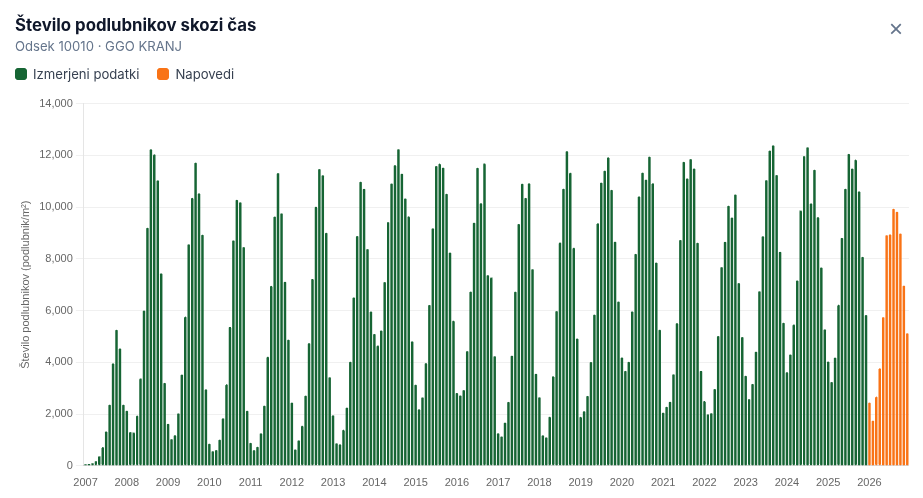

In [33]:
# Diagnostics: check whether target/pred arrays look like log1p or raw m3
h_cols = [f'h{i}' for i in range(1, 13)]
arr = target[h_cols].to_numpy(dtype=float)
arr_nz = arr[arr > 0]

print('target h1-h12 stats (all non-zero values):')
print(pd.Series(arr_nz).describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]).round(3).to_string())

print('\ny_true_log stats (from eval cell):')
print(pd.Series(y_true_log.ravel()).describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]).round(3).to_string())

print('\npreds_ev stats (from eval cell):')
print(pd.Series(preds_ev.ravel()).describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]).round(3).to_string())

mae_log = np.mean(np.abs(y_true_log - preds_ev), axis=0)
print('\nMAE in current scale (no expm1):')
print(pd.Series(mae_log, index=TARGET_COLS).round(3).to_string())

target h1-h12 stats (all non-zero values):
count    2729714.000
mean          56.100
std          117.627
min            0.050
50%           22.690
90%          129.360
95%          210.717
99%          523.650
99.9%       1374.170
max         4374.790

y_true_log stats (from eval cell):
count    1621596.000
mean           0.354
std            1.066
min            0.000
50%            0.000
90%            1.601
95%            3.326
99%            4.742
99.9%          5.807
max            7.882

preds_ev stats (from eval cell):
count    1621596.000
mean           3.495
std            1.118
min            0.395
50%            3.740
90%            4.778
95%            5.012
99%            5.348
99.9%          5.728
max            6.276

MAE in current scale (no expm1):
h1     2.124
h2     2.655
h3     2.500
h4     2.903
h5     2.763
h6     3.127
h7     3.611
h8     3.914
h9     4.052
h10    3.394
h11    3.787
h12    3.604
